# 04 — Few-Shot Training (Phase B)

Prototypical Network training on FineBadminton labeled data
with SSL pre-trained encoder from Phase A.

**Player ordering:** `FineBadmintonDataset` automatically reorders each skeleton so
the **hitting player is at nodes 0–16** and the opponent at nodes 17–33,
using the `"hitter"` field ("top"/"bottom") from the annotations.
This ensures the model always sees the strategically relevant player first.

**Pipeline:**
1. Load SSL pre-trained encoder (feature-layer aware)
2. Load FineBadminton labeled data with enriched features (L0–L3), hitter-first
3. 5-fold stratified CV with episodic sampling
4. Train ProtoNet (+ optional fine-tuning of encoder)
5. Evaluate: macro-F1, per-class F1, confusion matrix
6. Alternative classifiers: k-NN, linear probe
7. Save best prototypes and results

In [16]:
import subprocess
result = subprocess.run(['find', '/content/drive/MyDrive', '-name', 'config.py', '-path', '*/src/*'], capture_output=True, text=True)
print(result.stdout)


In [17]:
import os, sys, zipfile

# ── Colab setup (skipped when running locally) ───────────────────────────────
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    ZIP_PATH = '/content/drive/MyDrive/FineBadminton/baddiev2_colab.zip'
    PROJECT_PATH = '/content/Baddiev2'

    if not os.path.exists(PROJECT_PATH):
        print("Extracting project files...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(PROJECT_PATH)
        print("Done.")
    else:
        print("Project already extracted.")

    os.chdir(os.path.join(PROJECT_PATH, 'notebooks'))
    sys.path.insert(0, PROJECT_PATH)
    print(f"CWD: {os.getcwd()}")
    print(f"sys.path[0]: {sys.path[0]}")
else:
    print("Local run")

Local run


In [18]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # resolves relative to current CWD (set by Colab cell above)

import torch
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from pathlib import Path
from functools import partial

from src.config import *
from src.data.graph_builder import GraphBuilder
from src.data.dataset import FineBadmintonDataset, EpisodicSampler, collate_episode
from src.models.stgcn_model import STGCN
from src.models.transformer_encoder import SkeletonTransformer
from src.models.proto_net import PrototypicalNetwork

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Device: {device}")

# --- Skeleton source ---
# FB_SKELETONS           : original YOLOv8 (top-2 by confidence, ~14% chair umpire contamination)
# FB_SKELETONS_GDINO_V2  : GDINO-guided, all rallies — use this
SKELETON_DIR = FB_SKELETONS_GDINO_V2
print(f"Skeleton dir: {SKELETON_DIR}")

Device: cpu
Skeleton dir: /Users/yuen@backbase.com/Documents/Baddiev2/datasets_preprocessing/finebadminton_skeletons_gdino_v2


## 1. Configuration

In [19]:
cfg = get_config('fewshot')

# Feature layer — must match what was used for SSL pre-training
FEATURE_LAYER = 'L2'
feature_dim = FEATURE_DIMS[FEATURE_LAYER]
cfg.stgcn.in_channels = feature_dim

print(f"Feature layer: {FEATURE_LAYER} ({feature_dim} features/node)")
print(f"\nEncoder: ST-GCN")
print(f"  in_channels: {cfg.stgcn.in_channels}")
print(f"  num_nodes: {cfg.stgcn.num_nodes}")
print(f"  embedding_dim: {cfg.stgcn.embedding_dim}")
print(f"\nProtoNet:")
print(f"  n_way: {cfg.proto.n_way}")
print(f"  k_shot: {cfg.proto.k_shot}")
print(f"  n_query: {cfg.proto.n_query}")
print(f"  distance: {cfg.proto.distance}")
print(f"  episodes_per_epoch: {cfg.proto.episodes_per_epoch}")
print(f"  epochs: {cfg.proto.epochs}")
print(f"  fine_tune_encoder: {cfg.proto.fine_tune_encoder}")

Feature layer: L2 (9 features/node)

Encoder: ST-GCN
  in_channels: 9
  num_nodes: 34
  embedding_dim: 256

ProtoNet:
  n_way: 5
  k_shot: 10
  n_query: 5
  distance: euclidean
  episodes_per_epoch: 100
  epochs: 50
  fine_tune_encoder: True


## 2. Build Encoder and Load Pre-trained Weights

In [20]:
# Build graph adjacency
graph_builder = GraphBuilder(
    use_inter_player=cfg.ablation.use_inter_player,
    single_player=cfg.ablation.single_player,
)
adjacency = graph_builder.build_adjacency().to(device)
print(f"Adjacency: {adjacency.shape}")

# Build encoder
encoder = STGCN(
    in_channels=cfg.stgcn.in_channels,
    num_nodes=cfg.stgcn.num_nodes,
    adjacency=adjacency,
    num_layers=cfg.stgcn.num_layers,
    base_channels=cfg.stgcn.base_channels,
    embedding_dim=cfg.stgcn.embedding_dim,
    temporal_kernel=cfg.stgcn.temporal_kernel,
    dropout=cfg.stgcn.dropout,
).to(device)

total_params = sum(p.numel() for p in encoder.parameters())
print(f"Encoder parameters: {total_params:,}")

# Load SSL pre-trained weights
ssl_path = MODELS_DIR / f'ssl_pretrained_{FEATURE_LAYER}.pt'
ssl_checkpoint = None

if ssl_path.exists() and cfg.ablation.use_pretrained:
    ssl_checkpoint = torch.load(ssl_path, map_location=device, weights_only=False)
    encoder.load_state_dict(ssl_checkpoint['encoder_state_dict'])
    print(f"Loaded SSL weights from {ssl_path}")
    print(f"  SSL feature layer: {ssl_checkpoint.get('feature_layer', 'unknown')}")
    if 'history' in ssl_checkpoint:
        final_loss = ssl_checkpoint['history']['loss'][-1]
        print(f"  Final SSL loss: {final_loss:.4f}")
else:
    print(f"No SSL weights found at {ssl_path}")
    print("Using randomly initialized encoder")

Adjacency: torch.Size([3, 34, 34])


/Users/yuen@backbase.com/Documents/Baddiev2/src/data/graph_builder.py:133: RuntimeWarning: divide by zero encountered in power
  D_inv_sqrt = np.where(D > 0, np.power(D, -0.5), 0)


Encoder parameters: 3,083,199
Loaded SSL weights from /Users/yuen@backbase.com/Documents/Baddiev2/models/ssl_pretrained_L2.pt
  SSL feature layer: L2
  Final SSL loss: 0.7052


In [25]:
# Hit/shot type auxiliary head config (Phase B)
HIT_TYPE_AUX_WEIGHT = 0.3  # same weight as SSL aux loss in Phase A

# determine which auxiliary labels are available (FineBadminton vs. ShuttleSet)
if 'NUM_FB_HIT_TYPES' in globals():
    aux_label_name = 'FB hit types'
    aux_types = FB_HIT_TYPES
    num_aux_types = NUM_FB_HIT_TYPES
elif 'NUM_SS_SHOT_TYPES' in globals():
    aux_label_name = 'SS shot types'
    aux_types = SS_SHOT_TYPES
    num_aux_types = NUM_SS_SHOT_TYPES
else:
    aux_label_name = 'aux labels'
    aux_types = []
    num_aux_types = 0

print(f"{aux_label_name} ({num_aux_types} classes): {aux_types}")
print(f"Auxiliary loss weight: {HIT_TYPE_AUX_WEIGHT}")

aux labels (0 classes): []
Auxiliary loss weight: 0.3


## 3. Load FineBadminton Data

In [27]:
dataset = FineBadmintonDataset(
    skeleton_dir=SKELETON_DIR,
    shot_window=cfg.data.shot_window,
    feature_layer=FEATURE_LAYER,
)
print(f"Dataset size: {len(dataset)}")

# Show class distribution
from collections import Counter
label_dist = Counter(dataset.get_labels())
print(f"\nClass distribution:")
for idx in sorted(label_dist.keys()):
    print(f"  {IDX_TO_STRATEGY[idx]}: {label_dist[idx]}")

# Show how many samples actually have skeleton files
has_skel = sum(1 for info in dataset.rally_info if info['has_skeleton'])
print(f"\nSamples with skeleton files: {has_skel}/{len(dataset)}")

# Get cross-validation splits
splits = dataset.get_fold_splits(n_folds=cfg.data.num_folds, seed=cfg.data.random_seed)
print(f"\nFolds: {len(splits)}")
for i, (train, val, test) in enumerate(splits):
    print(f"  Fold {i+1}: train={len(train)}, val={len(val)}, test={len(test)}")

# Build hit/shot type label array for Phase B auxiliary loss
if 'FB_HIT_TYPE_TO_IDX' in globals():
    hit_type_labels_all = np.array([
        FB_HIT_TYPE_TO_IDX.get(info.get('hit_type', '').lower().strip(), -1)
        for info in dataset.rally_info
    ])
    aux_label_name = 'hit type'
elif 'SS_SHOT_TYPE_TO_IDX' in globals():
    hit_type_labels_all = np.array([
        SS_SHOT_TYPE_TO_IDX.get(info.get('shot_type', ''), -1)
        for info in dataset.rally_info
    ])
    aux_label_name = 'shot type'
else:
    hit_type_labels_all = np.array([-1] * len(dataset))
    aux_label_name = 'aux label'

valid_ht = (hit_type_labels_all >= 0).sum()
print(f"\n{aux_label_name.capitalize()} coverage: {valid_ht}/{len(dataset)} shots have {aux_label_name} labels")


[INFO] FineBadminton: 296 labeled shots across 40 rallies
  intercept: 108
  create_depth: 61
  defensive: 59
  passive: 50
  move_to_net: 18
Dataset size: 296

Class distribution:
  intercept: 108
  defensive: 59
  move_to_net: 18
  create_depth: 61
  passive: 50

Samples with skeleton files: 296/296

Folds: 5
  Fold 1: train=177, val=59, test=60
  Fold 2: train=177, val=60, test=59
  Fold 3: train=177, val=60, test=59
  Fold 4: train=177, val=60, test=59
  Fold 5: train=177, val=60, test=59

Shot type coverage: 0/296 shots have shot type labels


## 4. Helper Functions

In [28]:
def extract_embeddings(encoder, dataset, indices, device):
    """Extract embeddings for a subset of the dataset."""
    encoder.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for i in indices:
            x, y = dataset[i]
            x = x.unsqueeze(0).to(device)
            emb = encoder(x).cpu().numpy()[0]
            embeddings.append(emb)
            labels.append(y)
    return np.array(embeddings), np.array(labels)


def train_one_epoch(encoder, proto_net, dataset, train_idx, optimizer, cfg, device,
                    hit_type_head=None, hit_type_labels_all=None, aux_weight=0.3):
    """Train one epoch of episodic training with optional hit type auxiliary loss."""
    encoder.train()
    if hit_type_head is not None:
        hit_type_head.train()
    train_labels = [dataset.get_labels()[i] for i in train_idx]

    sampler = EpisodicSampler(
        labels=train_labels,
        n_way=cfg.proto.n_way,
        k_shot=cfg.proto.k_shot,
        n_query=cfg.proto.n_query,
        episodes_per_epoch=cfg.proto.episodes_per_epoch,
    )

    per_class = cfg.proto.k_shot + cfg.proto.n_query
    epoch_loss, epoch_acc, n_episodes = 0.0, 0.0, 0

    for episode_indices in sampler:
        actual_indices = [train_idx[i] for i in episode_indices]

        batch = [dataset[i] for i in actual_indices]
        support_x, support_y, query_x, query_y = collate_episode(
            batch, cfg.proto.n_way, cfg.proto.k_shot, cfg.proto.n_query
        )

        support_x = support_x.to(device)
        support_y = support_y.to(device)
        query_x = query_x.to(device)
        query_y = query_y.to(device)

        support_emb = encoder(support_x)
        query_emb = encoder(query_x)

        n_way_actual = int(support_y.unique().numel())
        prototypes = proto_net.compute_prototypes(support_emb, support_y, n_way_actual)
        distances = proto_net.compute_distances(query_emb, prototypes)
        log_probs = torch.nn.functional.log_softmax(-distances, dim=1)
        proto_loss = torch.nn.functional.nll_loss(log_probs, query_y)

        # Hit type auxiliary loss
        # Reconstruct actual indices in collate_episode order (all support first, then all query)
        aux_loss = torch.tensor(0.0, device=device)
        if hit_type_head is not None and hit_type_labels_all is not None:
            n_way_ep = len(actual_indices) // per_class
            support_actual, query_actual = [], []
            for c in range(n_way_ep):
                base = c * per_class
                support_actual.extend(actual_indices[base:base + cfg.proto.k_shot])
                query_actual.extend(actual_indices[base + cfg.proto.k_shot:base + per_class])
            all_actual = support_actual + query_actual
            all_emb = torch.cat([support_emb, query_emb], dim=0)

            ht_labels = torch.tensor(
                [hit_type_labels_all[i] for i in all_actual],
                dtype=torch.long, device=device
            )
            valid_mask = ht_labels >= 0
            if valid_mask.sum() > 0:
                ht_logits = hit_type_head(all_emb[valid_mask])
                aux_loss = torch.nn.functional.cross_entropy(ht_logits, ht_labels[valid_mask])

        loss = proto_loss + aux_weight * aux_loss

        preds = (-distances).argmax(dim=1)
        acc = (preds == query_y).float().mean().item()

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc
        n_episodes += 1

    return epoch_loss / n_episodes, epoch_acc / n_episodes


def evaluate_protonet(encoder, dataset, support_idx, test_idx, device):
    """Evaluate ProtoNet: compute prototypes from support, classify test."""
    support_emb, support_labels = extract_embeddings(encoder, dataset, support_idx, device)
    test_emb, test_labels = extract_embeddings(encoder, dataset, test_idx, device)

    prototypes = {}
    for c in np.unique(support_labels):
        prototypes[c] = support_emb[support_labels == c].mean(axis=0)

    preds = []
    for emb in test_emb:
        dists = {c: np.linalg.norm(emb - p) for c, p in prototypes.items()}
        preds.append(min(dists, key=dists.get))
    preds = np.array(preds)

    all_labels_list = list(range(NUM_CLASSES))
    macro_f1 = f1_score(test_labels, preds, average='macro',
                        labels=all_labels_list, zero_division=0)
    per_class = f1_score(test_labels, preds, average=None,
                         labels=all_labels_list, zero_division=0)
    cm = confusion_matrix(test_labels, preds, labels=all_labels_list)
    report = classification_report(
        test_labels, preds,
        labels=all_labels_list,
        target_names=STRATEGY_CLASSES,
        output_dict=True,
        zero_division=0,
    )

    return {
        'macro_f1': macro_f1,
        'per_class_f1': per_class.tolist(),
        'confusion_matrix': cm,
        'report': report,
        'prototypes': prototypes,
        'predictions': preds,
        'true_labels': test_labels,
    }


## 5. Episodic Training Loop (5-Fold CV)

In [29]:
all_fold_results = []
training_history = []

for fold_idx, (train_idx, val_idx, test_idx) in enumerate(splits):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx + 1}/{len(splits)}")
    print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

    # Reset encoder to SSL pre-trained weights for each fold
    if ssl_checkpoint is not None:
        encoder.load_state_dict(ssl_checkpoint['encoder_state_dict'])
    else:
        encoder = STGCN(
            in_channels=cfg.stgcn.in_channels,
            num_nodes=cfg.stgcn.num_nodes,
            adjacency=adjacency,
            num_layers=cfg.stgcn.num_layers,
            base_channels=cfg.stgcn.base_channels,
            embedding_dim=cfg.stgcn.embedding_dim,
            temporal_kernel=cfg.stgcn.temporal_kernel,
            dropout=cfg.stgcn.dropout,
        ).to(device)

    # Reset hit/shot type head for each fold
    hit_type_head = torch.nn.Linear(cfg.stgcn.embedding_dim, num_aux_types).to(device)

    proto_net = PrototypicalNetwork(encoder, distance=cfg.proto.distance)

    if cfg.proto.fine_tune_encoder:
        optimizer = optim.Adam([
            {'params': encoder.parameters(), 'lr': cfg.proto.lr * cfg.proto.encoder_lr_scale},
            {'params': hit_type_head.parameters(), 'lr': cfg.proto.lr},
        ], weight_decay=1e-5)
    else:
        encoder.eval()
        for p in encoder.parameters():
            p.requires_grad = False
        optimizer = optim.Adam(hit_type_head.parameters(), lr=cfg.proto.lr, weight_decay=1e-5)

    fold_history = {'train_loss': [], 'train_acc': [], 'val_f1': []}
    best_val_f1 = 0.0
    best_encoder_state = None
    best_hit_type_head_state = None

    for epoch in range(cfg.proto.epochs):
        train_loss, train_acc = train_one_epoch(
            encoder, proto_net, dataset, train_idx, optimizer, cfg, device,
            hit_type_head=hit_type_head,
            hit_type_labels_all=hit_type_labels_all,
            aux_weight=HIT_TYPE_AUX_WEIGHT,
        )
        fold_history['train_loss'].append(train_loss)
        fold_history['train_acc'].append(train_acc)

        if (epoch + 1) % 5 == 0:
            val_result = evaluate_protonet(encoder, dataset, train_idx, val_idx, device)
            fold_history['val_f1'].append(val_result['macro_f1'])

            if val_result['macro_f1'] > best_val_f1:
                best_val_f1 = val_result['macro_f1']
                best_encoder_state = {k: v.clone() for k, v in encoder.state_dict().items()}
                best_hit_type_head_state = {k: v.clone() for k, v in hit_type_head.state_dict().items()}

            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1}/{cfg.proto.epochs} — "
                      f"Loss: {train_loss:.4f}, Acc: {train_acc:.3f}, "
                      f"Val-F1: {val_result['macro_f1']:.3f}")

    if best_encoder_state is not None:
        encoder.load_state_dict(best_encoder_state)
    if best_hit_type_head_state is not None:
        hit_type_head.load_state_dict(best_hit_type_head_state)

    test_result = evaluate_protonet(encoder, dataset, train_idx, test_idx, device)

    print(f"\n  Test Macro-F1: {test_result['macro_f1']:.3f}")
    print(f"  Per-class F1: {[f'{f:.3f}' for f in test_result['per_class_f1']]}")
    print(f"  Best Val-F1: {best_val_f1:.3f}")

    fold_result = {
        'fold': fold_idx,
        'macro_f1': test_result['macro_f1'],
        'per_class_f1': test_result['per_class_f1'],
        'confusion_matrix': test_result['confusion_matrix'],
        'report': test_result['report'],
        'best_val_f1': best_val_f1,
        'prototypes': test_result['prototypes'],
    }
    all_fold_results.append(fold_result)
    training_history.append(fold_history)

f1_scores = [r['macro_f1'] for r in all_fold_results]
print(f"\n{'='*60}")
print(f"Overall Macro-F1: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"Per-fold: {[f'{f:.3f}' for f in f1_scores]}")


Fold 1/5
Train: 177, Val: 59, Test: 60


/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


  Epoch 10/50 — Loss: 1.0549, Acc: 0.591, Val-F1: 0.403
  Epoch 20/50 — Loss: 0.6547, Acc: 0.740, Val-F1: 0.390
  Epoch 30/50 — Loss: 0.4444, Acc: 0.839, Val-F1: 0.384
  Epoch 40/50 — Loss: 0.2848, Acc: 0.898, Val-F1: 0.406
  Epoch 50/50 — Loss: 0.2205, Acc: 0.923, Val-F1: 0.390

  Test Macro-F1: 0.353
  Per-class F1: ['0.500', '0.500', '0.000', '0.480', '0.286']
  Best Val-F1: 0.416

Fold 2/5
Train: 177, Val: 60, Test: 59


/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


  Epoch 10/50 — Loss: 1.0093, Acc: 0.586, Val-F1: 0.327
  Epoch 20/50 — Loss: 0.6246, Acc: 0.753, Val-F1: 0.327
  Epoch 30/50 — Loss: 0.3747, Acc: 0.860, Val-F1: 0.291
  Epoch 40/50 — Loss: 0.2276, Acc: 0.918, Val-F1: 0.294
  Epoch 50/50 — Loss: 0.1339, Acc: 0.951, Val-F1: 0.231

  Test Macro-F1: 0.420
  Per-class F1: ['0.650', '0.522', '0.000', '0.643', '0.286']
  Best Val-F1: 0.336

Fold 3/5
Train: 177, Val: 60, Test: 59


...

  Epoch 10/50 — Loss: 0.9882, Acc: 0.606, Val-F1: 0.422
  Epoch 20/50 — Loss: 0.5777, Acc: 0.780, Val-F1: 0.410
  Epoch 30/50 — Loss: 0.3331, Acc: 0.880, Val-F1: 0.400
  Epoch 40/50 — Loss: 0.1739, Acc: 0.945, Val-F1: 0.427
  Epoch 50/50 — Loss: 0.1253, Acc: 0.954, Val-F1: 0.423

  Test Macro-F1: 0.343
  Per-class F1: ['0.486', '0.538', '0.000', '0.609', '0.083']
  Best Val-F1: 0.427

Fold 4/5
Train: 177, Val: 60, Test: 59


/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


  Epoch 10/50 — Loss: 0.9534, Acc: 0.608, Val-F1: 0.353
  Epoch 20/50 — Loss: 0.5632, Acc: 0.768, Val-F1: 0.427
  Epoch 30/50 — Loss: 0.3476, Acc: 0.874, Val-F1: 0.443
  Epoch 40/50 — Loss: 0.2112, Acc: 0.925, Val-F1: 0.501
  Epoch 50/50 — Loss: 0.1641, Acc: 0.940, Val-F1: 0.511

  Test Macro-F1: 0.364
  Per-class F1: ['0.634', '0.480', '0.182', '0.400', '0.125']
  Best Val-F1: 0.511

Fold 5/5
Train: 177, Val: 60, Test: 59


/Users/yuen@backbase.com/Documents/Baddiev2/.venv/lib/python3.10/site-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


  Epoch 10/50 — Loss: 0.9924, Acc: 0.589, Val-F1: 0.417
  Epoch 20/50 — Loss: 0.6515, Acc: 0.745, Val-F1: 0.487
  Epoch 30/50 — Loss: 0.4173, Acc: 0.833, Val-F1: 0.526
  Epoch 40/50 — Loss: 0.2251, Acc: 0.916, Val-F1: 0.497
  Epoch 50/50 — Loss: 0.1265, Acc: 0.960, Val-F1: 0.462

  Test Macro-F1: 0.324
  Per-class F1: ['0.410', '0.417', '0.000', '0.640', '0.154']
  Best Val-F1: 0.526

Overall Macro-F1: 0.361 ± 0.032
Per-fold: ['0.353', '0.420', '0.343', '0.364', '0.324']


---
## 6. Training Curves

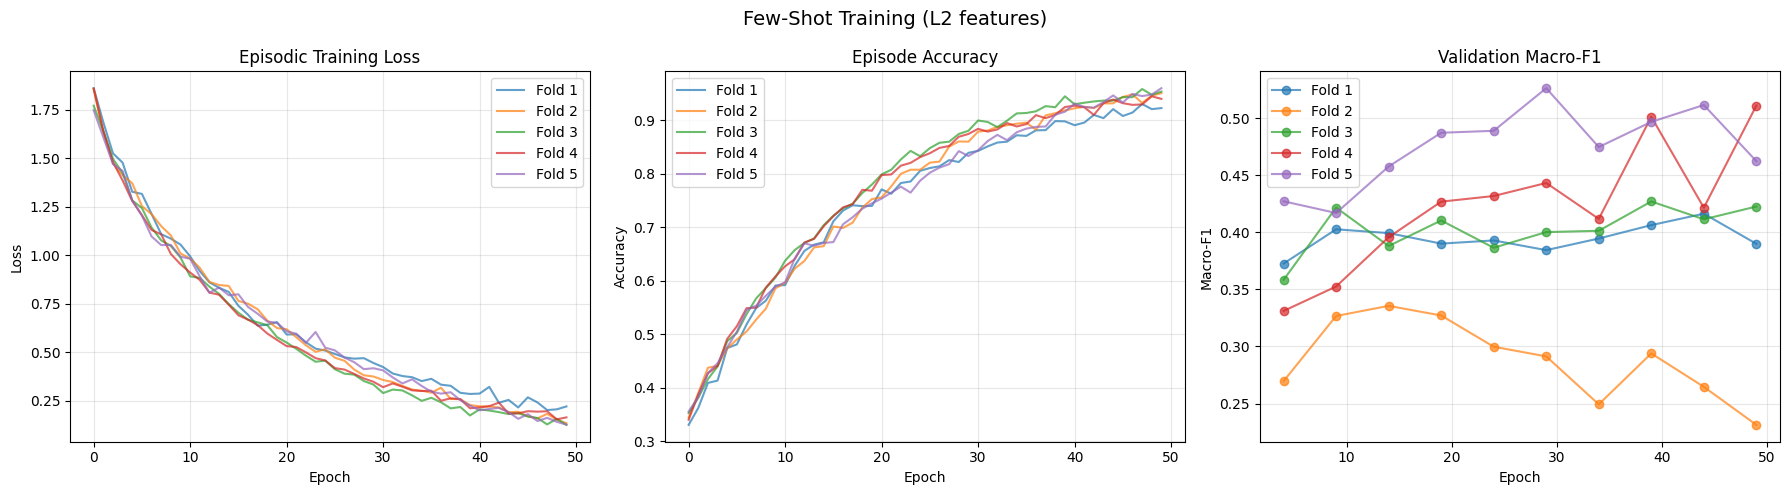

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, hist in enumerate(training_history):
    axes[0].plot(hist['train_loss'], alpha=0.7, label=f'Fold {i+1}')
    axes[1].plot(hist['train_acc'], alpha=0.7, label=f'Fold {i+1}')
    val_epochs = list(range(4, len(hist['train_loss']), 5))
    axes[2].plot(val_epochs, hist['val_f1'], 'o-', alpha=0.7, label=f'Fold {i+1}')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Episodic Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Episode Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1')
axes[2].set_title('Validation Macro-F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Few-Shot Training ({FEATURE_LAYER} features)', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fewshot_training_curves.png', dpi=150)
plt.show()

---
## 7. Confusion Matrix

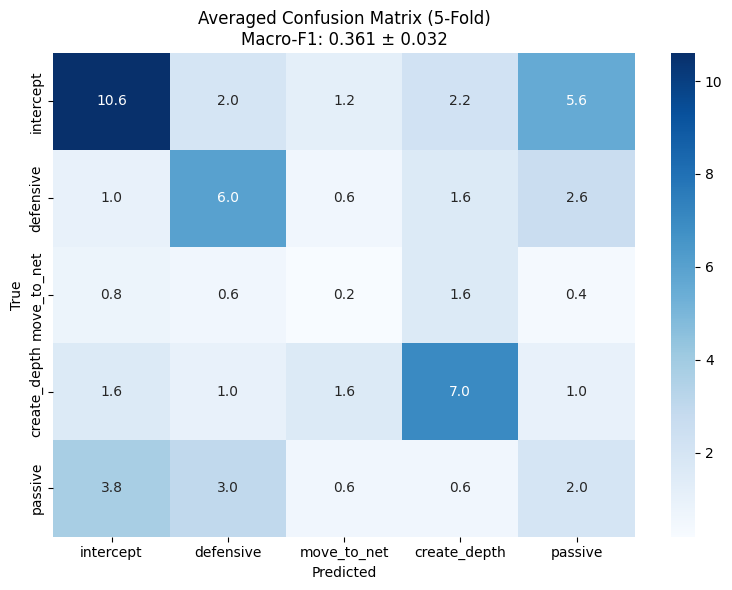

Per-class F1 (mean ± std):
  intercept      : 0.536 ± 0.092
  defensive      : 0.491 ± 0.042
  move_to_net    : 0.036 ± 0.073
  create_depth   : 0.554 ± 0.097
  passive        : 0.187 ± 0.084


In [32]:
# Averaged confusion matrix across folds
avg_cm = np.mean([r['confusion_matrix'] for r in all_fold_results], axis=0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    avg_cm, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=STRATEGY_CLASSES,
    yticklabels=STRATEGY_CLASSES,
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Averaged Confusion Matrix (5-Fold)\nMacro-F1: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fewshot_confusion_matrix.png', dpi=150)
plt.show()

# Per-class F1 summary
per_class_f1s = np.array([r['per_class_f1'] for r in all_fold_results])
print("Per-class F1 (mean ± std):")
for i, name in enumerate(STRATEGY_CLASSES):
    if i < per_class_f1s.shape[1]:
        print(f"  {name:15s}: {per_class_f1s[:, i].mean():.3f} ± {per_class_f1s[:, i].std():.3f}")

---
## 8. Alternative Classifiers (k-NN, Linear Probe)

Compare ProtoNet against k-NN and logistic regression
using the same frozen encoder embeddings.

In [33]:
# Use the best encoder from the last fold (or reload SSL weights)
if ssl_checkpoint is not None:
    encoder.load_state_dict(ssl_checkpoint['encoder_state_dict'])

# Extract all embeddings once
all_emb, all_labels = extract_embeddings(
    encoder, dataset, list(range(len(dataset))), device
)
print(f"Embeddings: {all_emb.shape}")

# Compare classifiers across folds
classifier_results = {
    'protonet': [],
    'knn_3': [],
    'knn_5': [],
    'linear_probe': [],
}

for fold_idx, (train_idx, val_idx, test_idx) in enumerate(splits):
    X_train = all_emb[train_idx]
    y_train = all_labels[train_idx]
    X_test = all_emb[test_idx]
    y_test = all_labels[test_idx]

    # ProtoNet (nearest centroid)
    prototypes = {}
    for c in np.unique(y_train):
        prototypes[c] = X_train[y_train == c].mean(axis=0)
    proto_preds = np.array([
        min(prototypes, key=lambda c: np.linalg.norm(x - prototypes[c]))
        for x in X_test
    ])
    classifier_results['protonet'].append(
        f1_score(y_test, proto_preds, average='macro')
    )

    # k-NN (k=3)
    knn3 = KNeighborsClassifier(n_neighbors=3)
    knn3.fit(X_train, y_train)
    classifier_results['knn_3'].append(
        f1_score(y_test, knn3.predict(X_test), average='macro')
    )

    # k-NN (k=5)
    knn5 = KNeighborsClassifier(n_neighbors=5)
    knn5.fit(X_train, y_train)
    classifier_results['knn_5'].append(
        f1_score(y_test, knn5.predict(X_test), average='macro')
    )

    # Linear probe (logistic regression)
    lr = LogisticRegression(max_iter=1000, C=1.0)
    lr.fit(X_train, y_train)
    classifier_results['linear_probe'].append(
        f1_score(y_test, lr.predict(X_test), average='macro')
    )

# Summary table
print(f"\n{'Method':<15} {'Macro-F1':>12} {'Std':>8}")
print("-" * 38)
for method, f1s in classifier_results.items():
    print(f"{method:<15} {np.mean(f1s):>12.3f} {np.std(f1s):>8.3f}")

Embeddings: (296, 256)

Method              Macro-F1      Std
--------------------------------------
protonet               0.206    0.036
knn_3                  0.328    0.052
knn_5                  0.308    0.050
linear_probe           0.362    0.039


---
## 9. Save Results and Best Model

In [34]:
# Save best fold prototypes and encoder for inference
best_fold = max(range(len(all_fold_results)), key=lambda i: all_fold_results[i]['macro_f1'])
best_result = all_fold_results[best_fold]
print(f"Best fold: {best_fold + 1} (Macro-F1: {best_result['macro_f1']:.3f})")

proto_tensors = {c: torch.tensor(p) for c, p in best_result['prototypes'].items()}

checkpoint = {
    'encoder_state_dict': encoder.state_dict(),
    'hit_type_head_state_dict': hit_type_head.state_dict(),
    'prototypes': proto_tensors,
    'feature_layer': FEATURE_LAYER,
    'hit_types': aux_types,
    'config': cfg,
    'fold_results': [
        {k: v.tolist() if isinstance(v, np.ndarray) else v
         for k, v in r.items() if k != 'prototypes'}
        for r in all_fold_results
    ],
    'classifier_comparison': {
        method: {'mean': float(np.mean(f1s)), 'std': float(np.std(f1s)), 'folds': f1s}
        for method, f1s in classifier_results.items()
    },
}

save_path = MODELS_DIR / f'fewshot_{FEATURE_LAYER}.pt'
torch.save(checkpoint, save_path)
print(f"Saved to {save_path}")

json_results = {
    'feature_layer': FEATURE_LAYER,
    'overall_macro_f1': float(np.mean(f1_scores)),
    'overall_std': float(np.std(f1_scores)),
    'fold_f1s': [float(f) for f in f1_scores],
    'classifier_comparison': checkpoint['classifier_comparison'],
}
with open(RESULTS_DIR / 'fewshot_results.json', 'w') as f:
    json.dump(json_results, f, indent=2)
print(f"Results saved to {RESULTS_DIR / 'fewshot_results.json'}")

Best fold: 2 (Macro-F1: 0.420)
Saved to /Users/yuen@backbase.com/Documents/Baddiev2/models/fewshot_L2.pt
Results saved to /Users/yuen@backbase.com/Documents/Baddiev2/results/fewshot_results_sslfewshot.json
